In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# imports

In [1]:
import os
import glob
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
from torchvision.utils import make_grid
from tqdm.auto import tqdm

from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

Device: cuda


# Hyper-params initialization

In [6]:
# Select task: 'face' or 'anime'
DATASET_MODE = 'face'

IMG_SIZE = 256
BATCH_SIZE = 16
EPOCHS = 50
LR = 0.0002
BETA1 = 0.5
BETA2 = 0.999
LAMBDA_L1 = 100
NUM_WORKERS = 2

FACE_PATH = "/kaggle/input/datasets/arbazkhan971/cuhk-face-sketch-database-cufs"
ANIME_PATH = "/kaggle/input/datasets/ktaebum/anime-sketch-colorization-pair"

# transformation

In [7]:
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

# Dataset

In [8]:
class PairedDataset(Dataset):
    def __init__(self, input_dir, target_dir):
        # Grab all input sketches
        all_input_images = sorted(glob.glob(input_dir + "/*"))
        
        self.input_images = []
        self.target_images = []
        
        # Explicitly match filenames to prevent mismatched pairs
        for input_path in all_input_images:
            basename = os.path.basename(input_path)
            target_path = os.path.join(target_dir, basename)
            
            # Only add to our lists if the exact matching file exists in both folders
            if os.path.exists(target_path):
                self.input_images.append(input_path)
                self.target_images.append(target_path)
                
        self.length = len(self.input_images)
        
    def __len__(self):
        return self.length
    
    def __getitem__(self, idx):
        x = Image.open(self.input_images[idx]).convert("RGB")
        y = Image.open(self.target_images[idx]).convert("RGB")
        
        x = transform(x)
        y = transform(y)
        
        return x, y

# dataset paths

In [9]:
if DATASET_MODE == 'face':
    input_dir = FACE_PATH + "/sketches"
    target_dir = FACE_PATH + "/photos"

elif DATASET_MODE == 'anime':
    input_dir = ANIME_PATH + "/sketch"
    target_dir = ANIME_PATH + "/color"

dataset = PairedDataset(input_dir, target_dir)

train_size = int(0.9 * len(dataset))
val_size = len(dataset) - train_size

train_data, val_data = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader = DataLoader(val_data, batch_size=4, shuffle=False)

print("Total:", len(dataset))
print("Train:", len(train_data))
print("Val:", len(val_data))

Total: 188
Train: 169
Val: 19


# Generator

In [10]:
class DownBlock(nn.Module):
    def __init__(self, in_c, out_c, bn=True):
        super().__init__()
        layers = [
            nn.Conv2d(in_c, out_c, 4, 2, 1, bias=False)
        ]
        if bn:
            layers.append(nn.BatchNorm2d(out_c))
        layers.append(nn.LeakyReLU(0.2))
        self.block = nn.Sequential(*layers)
        
    def forward(self, x):
        return self.block(x)


class UpBlock(nn.Module):
    def __init__(self, in_c, out_c, dropout=False):
        super().__init__()
        layers = [
            nn.ConvTranspose2d(in_c, out_c, 4, 2, 1, bias=False),
            nn.BatchNorm2d(out_c),
            nn.ReLU()
        ]
        if dropout:
            layers.append(nn.Dropout(0.5))
        self.block = nn.Sequential(*layers)
        
    def forward(self, x):
        return self.block(x)

# generator

In [11]:
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.d1 = DownBlock(3,64,bn=False)
        self.d2 = DownBlock(64,128)
        self.d3 = DownBlock(128,256)
        self.d4 = DownBlock(256,512)
        self.d5 = DownBlock(512,512)
        self.d6 = DownBlock(512,512)
        self.d7 = DownBlock(512,512)
        
        self.bottleneck = nn.Sequential(
            nn.Conv2d(512,512,4,2,1),
            nn.ReLU()
        )
        
        self.u1 = UpBlock(512,512,dropout=True)
        self.u2 = UpBlock(1024,512,dropout=True)
        self.u3 = UpBlock(1024,512,dropout=True)
        self.u4 = UpBlock(1024,512)
        self.u5 = UpBlock(1024,256)
        self.u6 = UpBlock(512,128)
        self.u7 = UpBlock(256,64)
        
        self.final = nn.Sequential(
            nn.ConvTranspose2d(128,3,4,2,1),
            nn.Tanh()
        )
        
    def forward(self,x):
        d1 = self.d1(x)
        d2 = self.d2(d1)
        d3 = self.d3(d2)
        d4 = self.d4(d3)
        d5 = self.d5(d4)
        d6 = self.d6(d5)
        d7 = self.d7(d6)
        
        b = self.bottleneck(d7)
        
        u1 = self.u1(b)
        u2 = self.u2(torch.cat([u1,d7],1))
        u3 = self.u3(torch.cat([u2,d6],1))
        u4 = self.u4(torch.cat([u3,d5],1))
        u5 = self.u5(torch.cat([u4,d4],1))
        u6 = self.u6(torch.cat([u5,d3],1))
        u7 = self.u7(torch.cat([u6,d2],1))
        
        return self.final(torch.cat([u7,d1],1))

# Discriminator (Patch GAN)

In [12]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(

            # 256 -> 128
            nn.Conv2d(6, 64, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),

            # 128 -> 64
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            # 64 -> 32
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),

            # 32 -> 16
            nn.Conv2d(256, 512, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),

            # keep 16x16
            nn.Conv2d(512, 1, kernel_size=3, stride=1, padding=1)
        )

    def forward(self, x, y):
        inp = torch.cat([x, y], dim=1)
        return self.model(inp)

# initialize models

In [13]:
gen = Generator().to(device)
disc = Discriminator().to(device)

# Wrap models in DataParallel to utilize both Kaggle T4 GPUs
if torch.cuda.device_count() > 1:
    print(f"Using {torch.cuda.device_count()} GPUs!")
    gen = nn.DataParallel(gen)
    disc = nn.DataParallel(disc)

print("Models Loaded")

Models Loaded


# Loss Function

In [14]:
bce = nn.BCEWithLogitsLoss()
l1 = nn.L1Loss()

opt_g = optim.Adam(gen.parameters(), lr=LR, betas=(BETA1,BETA2))
opt_d = optim.Adam(disc.parameters(), lr=LR, betas=(BETA1,BETA2))

scaler = torch.amp.GradScaler("cuda")

# evaluation metrics

In [15]:
g_losses = []
d_losses = []

for epoch in range(EPOCHS):
    
    gen.train()
    disc.train()
    
    total_g = 0
    total_d = 0
    
    for x,y in train_loader:
        x,y = x.to(device), y.to(device)
        
        # Train Discriminator
        with torch.amp.autocast("cuda"):
            fake = gen(x)
            
            real_pred = disc(x,y)
            fake_pred = disc(x,fake.detach())
            
            loss_d = (
                bce(real_pred, torch.ones_like(real_pred)) +
                bce(fake_pred, torch.zeros_like(fake_pred))
            ) / 2
            
        opt_d.zero_grad()
        scaler.scale(loss_d).backward()
        scaler.step(opt_d)
        
        # Train Generator
        with torch.amp.autocast("cuda"):
            fake_pred = disc(x,fake)
            
            adv_loss = bce(fake_pred, torch.ones_like(fake_pred))
            recon_loss = l1(fake,y)
            
            loss_g = adv_loss + LAMBDA_L1 * recon_loss
            
        opt_g.zero_grad()
        scaler.scale(loss_g).backward()
        scaler.step(opt_g)
        scaler.update()
        
        total_g += loss_g.item()
        total_d += loss_d.item()
        
    g_losses.append(total_g / len(train_loader))
    d_losses.append(total_d / len(train_loader))
    
    print(f"Epoch [{epoch+1}/{EPOCHS}] G:{g_losses[-1]:.4f} D:{d_losses[-1]:.4f}")
    
    if (epoch+1) % 5 == 0:
        torch.save(gen.state_dict(), f"/kaggle/working/gen_epoch_{epoch+1}.pth")

Epoch [1/50] G:56.7340 D:0.6026
Epoch [2/50] G:32.7965 D:0.4188
Epoch [3/50] G:29.4302 D:0.3163
Epoch [4/50] G:26.9931 D:0.4985
Epoch [5/50] G:26.5772 D:0.3089
Epoch [6/50] G:26.1988 D:0.2383
Epoch [7/50] G:26.3080 D:0.1941
Epoch [8/50] G:26.3901 D:0.1316
Epoch [9/50] G:25.9239 D:0.2846
Epoch [10/50] G:25.1774 D:0.4191
Epoch [11/50] G:24.7075 D:0.5312
Epoch [12/50] G:23.9185 D:0.3962
Epoch [13/50] G:23.3952 D:0.5209
Epoch [14/50] G:23.2340 D:0.4289
Epoch [15/50] G:21.9907 D:0.5244
Epoch [16/50] G:21.1465 D:0.4952
Epoch [17/50] G:20.8042 D:0.5620
Epoch [18/50] G:20.7111 D:0.5261
Epoch [19/50] G:19.9063 D:0.5381
Epoch [20/50] G:20.3415 D:0.5929
Epoch [21/50] G:19.8303 D:0.4643
Epoch [22/50] G:19.3115 D:0.4887
Epoch [23/50] G:18.3917 D:0.4962
Epoch [24/50] G:18.1838 D:0.4873
Epoch [25/50] G:18.1918 D:0.5468
Epoch [26/50] G:17.6876 D:0.4978
Epoch [27/50] G:16.8670 D:0.5650
Epoch [28/50] G:16.7226 D:0.5774
Epoch [29/50] G:16.3410 D:0.4789
Epoch [30/50] G:16.3655 D:0.5047
Epoch [31/50] G:16.

# loss graph

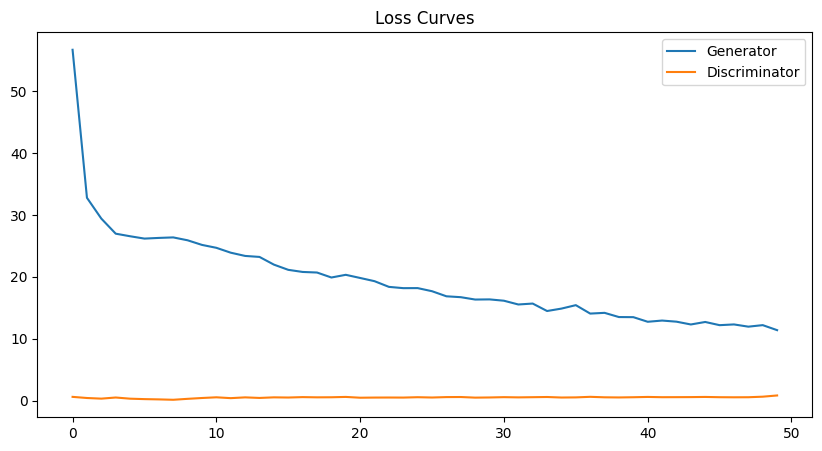

In [16]:
plt.figure(figsize=(10,5))
plt.plot(g_losses,label="Generator")
plt.plot(d_losses,label="Discriminator")
plt.legend()
plt.title("Loss Curves")
plt.show()

# visualization

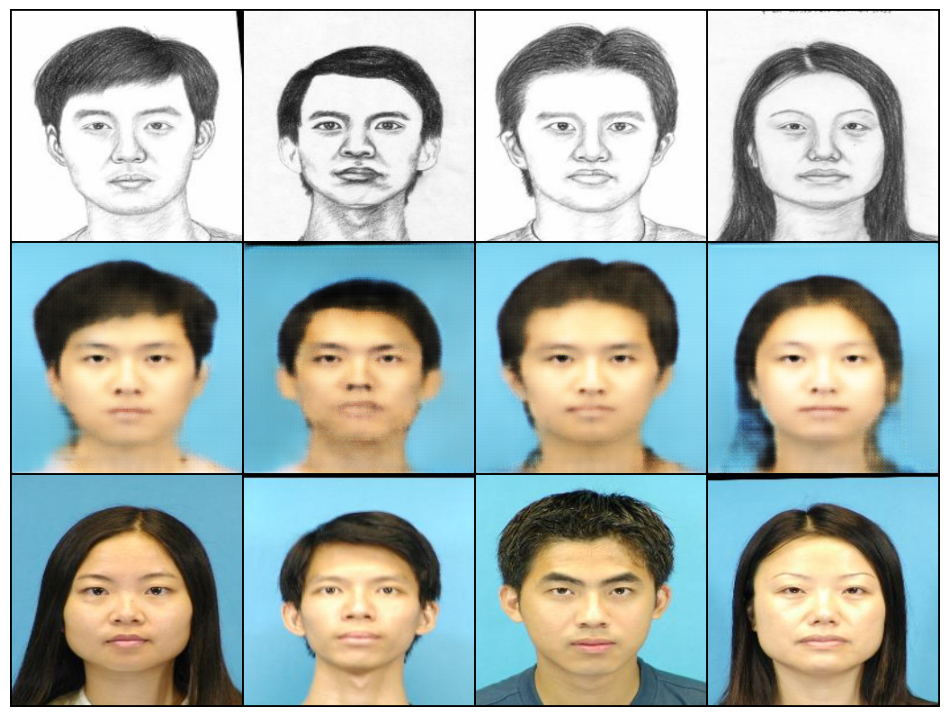

In [17]:
def denorm(x):
    return (x * 0.5 + 0.5).clamp(0,1)

gen.eval()

x,y = next(iter(val_loader))
x = x.to(device)

with torch.no_grad():
    fake = gen(x).cpu()

images = torch.cat([denorm(x.cpu()), denorm(fake), denorm(y)],0)

grid = make_grid(images,nrow=4)

plt.figure(figsize=(12,12))
plt.imshow(np.transpose(grid.numpy(),(1,2,0)))
plt.axis("off")
plt.show()

# ssim and psnr

In [18]:
gen.eval()

ssim_scores = []
psnr_scores = []

for x,y in val_loader:
    x = x.to(device)
    
    with torch.no_grad():
        fake = gen(x).cpu()
    
    fake = denorm(fake).numpy()
    y = denorm(y).numpy()
    
    for i in range(len(fake)):
        pred = np.transpose(fake[i],(1,2,0))
        real = np.transpose(y[i],(1,2,0))
        
        ssim_scores.append(
            ssim(real,pred,channel_axis=2,data_range=1.0)
        )
        
        psnr_scores.append(
            psnr(real,pred,data_range=1.0)
        )

print("Average SSIM:", np.mean(ssim_scores))
print("Average PSNR:", np.mean(psnr_scores))

Average SSIM: 0.55616534
Average PSNR: 14.595235412372775


# final model

In [19]:
torch.save(gen.state_dict(), "/kaggle/working/final_generator.pth")
print("Saved Successfully")

Saved Successfully
